In [80]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator

In [81]:
qc = QuantumCircuit(1)
qc.x(0)
qc.h(0)
qc.draw()

┌───┐┌───┐
q: ┤ X ├┤ H ├
   └───┘└───┘

In [82]:
q = Statevector(qc)
q


Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


In [83]:
q.probabilities()

array([0.5, 0.5])

In [84]:
q.sample_counts(100)

{np.str_('0'): np.int64(41), np.str_('1'): np.int64(59)}

In [85]:
U = Operator(qc)
U.draw('latex')


<IPython.core.display.Latex object>

In [86]:
X = Operator.from_label('X')
H = Operator.from_label('H')

In [87]:
U2 = H @ X
U2.draw('latex')

<IPython.core.display.Latex object>

In [97]:
from qiskit.providers.basic_provider import BasicSimulator
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2

In [89]:
qc = QuantumCircuit(1,1)
qc.x(0)
qc.h(0)
qc.measure(0,0)
qc.draw()

┌───┐┌───┐┌─┐
  q: ┤ X ├┤ H ├┤M├
     └───┘└───┘└╥┘
c: 1/═══════════╩═
                0

In [92]:
sim_basic = BasicSimulator()
sim_aer = AerSimulator()

In [95]:
counts_basic = sim_basic.run(qc, shots=100).result().get_counts()
counts_aer = sim_aer.run(qc, shots=100).result().get_counts()

In [96]:
print(counts_basic)
print(counts_aer)

{'0': 48, '1': 52}
{'0': 53, '1': 47}


In [99]:
samp_aer = SamplerV2(mode=sim_aer)

In [100]:
result = samp_aer.run([qc], shots=100).result()

In [101]:
counts_samp = result[0].data.c.get_counts()

In [102]:
counts_samp

{'0': 52, '1': 48}

In [103]:
from qiskit.visualization import plot_histogram

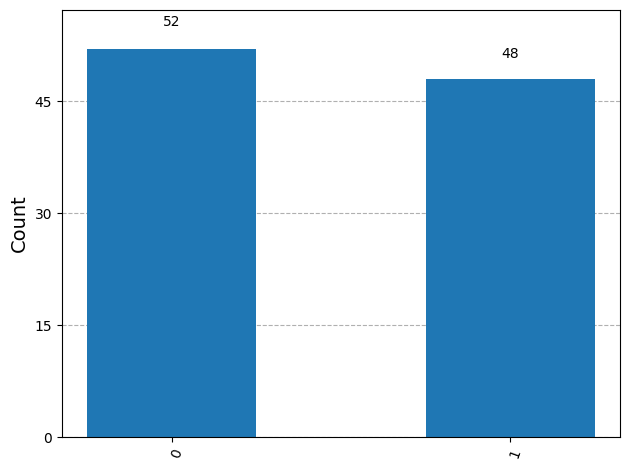

In [104]:
plot_histogram(counts_samp)